# Imbalanced Data

Imbalanced data (also called class-imbalanced data or the class imbalance problem) refers to a classification setting where the classes in a dataset are not represented equally - one class, called the `majority class`, contains substantially more instances than the other, called the `minority class`.

In [42]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
from numpy import where
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

## Handling the Imbalanced Data Problem

We will start by generating 2-D imbalanced data from two classes (9900 from class 0 and 100 from class 1).

Before Running SMOTE:  Counter({np.int64(0): 9900, np.int64(1): 100})


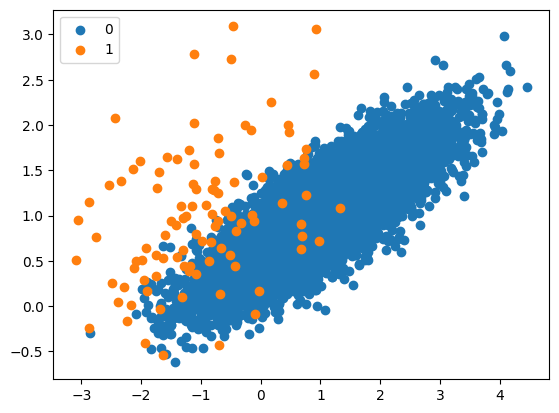

In [43]:
X_org, y_org = make_classification(n_samples=10000, n_features=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)
# summarize class distribution
counter = Counter(y_org)
print("Before Running SMOTE: ", counter)
for label, _ in counter.items():
    row_ix = where(y_org == label)[0]
    plt.scatter(X_org[row_ix, 0], X_org[row_ix, 1], label=str(label))
plt.legend()
plt.show()

We will split the data into training and testing set with 70/30 ratio. We will train a logistic regression model on the training data and evaluate its performance on the test data using three performance measures `F1-Score`, `Accuracy`, `Balanced Accuracy`.

In training:  Counter({np.int64(0): 6930, np.int64(1): 70})


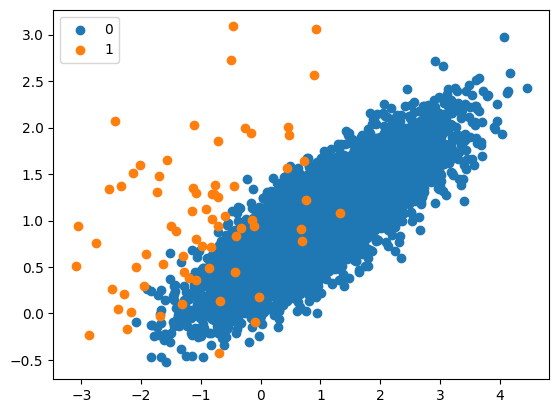

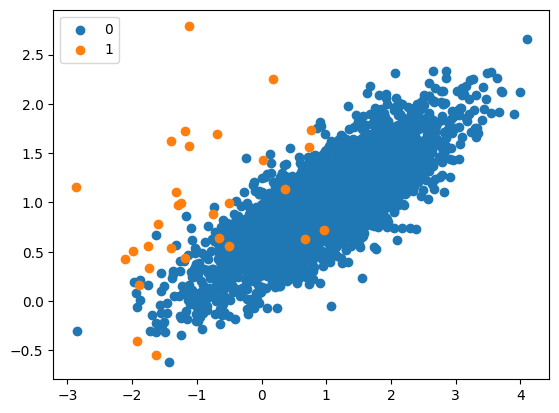

(7000, 3000)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_org, y_org, test_size = 0.30,
                                                    shuffle = True,
                                                    stratify = y_org)
# Plot the training
counter = Counter(y_train)
print("In training: ", counter)
for label, _ in counter.items():
    row_ix = where(y_train == label)[0]
    plt.scatter(X_train[row_ix, 0], X_train[row_ix, 1], label=str(label))
plt.legend()
plt.show()

# Plot the testing set

counter = Counter(y_test)
for label, _ in counter.items():
    row_ix = where(y_test == label)[0]
    plt.scatter(X_test[row_ix, 0], X_test[row_ix, 1], label=str(label))
plt.legend()
plt.show()

len(X_train), len(X_test)

In [45]:
# Train a logisitic regression model
# Train the model with the training subset
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Test the model on the test subset
result = logreg.predict(X_test)
# Display the confusion matrix to check the performance of your model
confusion_matrix(result, y_test)

array([[2967,   16],
       [   3,   14]])

In [46]:
f1 = f1_score(y_test, result, average=None)
acc = accuracy_score(y_test, result, normalize=True)
bacc = balanced_accuracy_score(y_test, result)
print ("F1-Score = {}\nAccuracy = {}\nBalanced Accuracy = {}".format(f1, acc, bacc))

F1-Score = [0.99680833 0.59574468]
Accuracy = 0.9936666666666667
Balanced Accuracy = 0.7328282828282828


To solve the imbalanced data problem, we will practice on two techniques:

- Generating more examples from the class of minority.
- Using cost sensitive classification.


## Synthetic Data Generation

We start with generating synthetic data from the minority using `SMOTE` and `GANs`.

### `SMOTE for Balancing Data`
The first technique that we will use is SMOTE. Make sure that you use only the training set to generate more examples.

After Running SMOTE Counter({np.int64(0): 6930, np.int64(1): 6930})


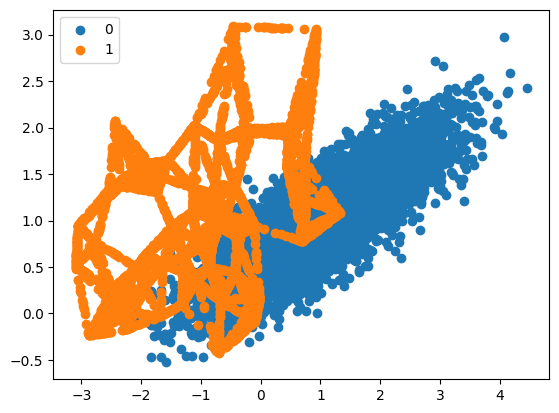

In [47]:
# transform the dataset
oversample = SMOTE()
X_OS, y_OS = oversample.fit_resample(X_train, y_train)
# summarize the new class distribution
counter = Counter(y_OS)
print("After Running SMOTE", counter)
# scatter plot of examples by class label
for label, _ in counter.items():
    row_ix = where(y_OS == label)[0]
    plt.scatter(X_OS[row_ix, 0], X_OS[row_ix, 1], label=str(label))
plt.legend()
plt.show()

In [48]:
# Train a logisitic regression model
# Train the model with the training subset
logreg = LogisticRegression()
logreg.fit(X_OS, y_OS)

# Test the model on the test subset
result = logreg.predict(X_test)
# Display the confusion matrix to check the performance of your model
confusion_matrix(result, y_test)

array([[2716,    4],
       [ 254,   26]])

In [49]:
f1 = f1_score(y_test, result, average=None)
acc = accuracy_score(y_test, result, normalize=True)
bacc = balanced_accuracy_score(y_test, result)
print ("F1-Score = {}\nAccuracy = {}\nBalanced Accuracy = {}".format(f1, acc, bacc))

F1-Score = [0.95465729 0.16774194]
Accuracy = 0.914
Balanced Accuracy = 0.8905723905723906


The classifier tend to classify more examples as negative than before so it is predicting more samples from the minority class. Keep this in mind so you can apply it for the fairness

`Note That`: SMOTE treats all the variables as numerical values from a continuous random variable. If you have categorical data, then you can use SMOTENC for mixed set of features (continuous, categorical) from the imblearn.over_sampling package.

### `C-GAN: Generate Synthetic Data`

CTGAN model is conditional generative network based on Deep Learning data synthesizing. The architecture is comprised of a generator and a discriminator model. The generator is responsible for generating new examples that, ideally, are indistinguishable from real examples in the dataset. The discriminator model is responsible for classifying a given example as either real (drawn from the dataset) or fake (generated).

The models are trained together in a zero-sum manner, such that improvements in the discriminator come at the cost of a reduced capability of the generator, and vice versa.

First, we will join the data values with their labels to be used by the GAN as training data.

You may need to install the sdv and ctgan packages using:

- !pip install sdv
- !pip install ctgan

If you are facing problems, you can check the documentation of ctgan [here](https://docs.sdv.dev/sdv$0). We will point to specific parts of the documentation later.

In [50]:
b = np.array([y_train])
data = np.concatenate((X_train, b.T), axis=1)
df = pd.DataFrame(data, columns=['x1', 'x2', 'y'])

You need to extract the metadata of the dataframe to define the synthesizer. Check [metadata](https://docs.sdv.dev/sdv/single-table-data/data-preparation/single-table-metadata-api$0) for more information.

In [51]:
#!pip install sdv
#!pip install sdv

In [52]:
from ctgan import CTGAN
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df)

We can display the collected information about the dataframe using:

In [53]:
python_dict = metadata.to_dict()
python_dict

{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'x1': {'sdtype': 'numerical'},
  'x2': {'sdtype': 'numerical'},
  'y': {'sdtype': 'categorical'}}}

Define a `CTGANSynthesizer` and pass the collected metadata to the defined object. Check this [link](https://docs.sdv.dev/sdv/modeling/single-table-synthesizers/ctgansynthesizer$0) for more information.

In [54]:
from sdv.single_table import CTGANSynthesizer

In [67]:
synthesizer = CTGANSynthesizer(metadata)
synthesizer.fit(df)

/usr/local/lib/python3.13/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


List the constraints that would you like to apply in order to generate values with specific characteristics. Here, we need to generate examples from the minority class `y = 1`. You need also to find how many examples you want to generate to have balanced dataset. For more information check this [link](https://docs.sdv.dev/sdv/sampling/conditional/single-table$0).

In [79]:
from sdv.sampling import Condition
counter = Counter(y_train)
needed_rows = counter[0] - counter[1]
cond = Condition(
    num_rows = needed_rows,
    column_values={'y': 1}
)
print(cond, needed_rows)

<sdv.sampling.tabular.Condition object at 0x799c9ad2ad70> 6860


Use the synthesizer to generate the required set of examples according to the conitions that you specfied in the previous step. Concatenate the generated examples with the examples from the original dataframe.

In [69]:
synthetic_data = synthesizer.sample_from_conditions(
    conditions=[cond],
    output_file_path = None
)
df_OS = pd.concat([df, synthetic_data])
df_OS.y.value_counts()

Sampling conditions: 100%|██████████| 6860/6860 [00:00<00:00, 9513.23it/s] 


,count
y,
0.0,6930
1.0,6930


You can plot the new dataframe to check the generated data.

After producing more examples from the minority class:  Counter({0.0: 6930, 1.0: 6930})


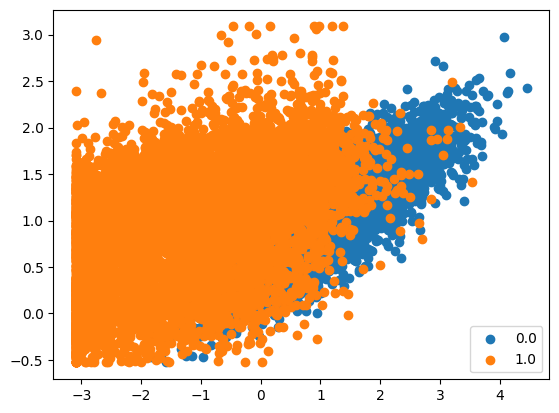

In [80]:
y_array = df_OS.y
counter = Counter(y_array)
print("After producing more examples from the minority class: ", counter)
X_array = np.array(df_OS.loc[:, df_OS.columns != 'y'])
for label, _ in counter.items():
    row_ix = where(y_array == label)[0]
    plt.scatter(X_array[row_ix, 0], X_array[row_ix, 1], label=str(label))
plt.legend()
plt.show()

Train a logistic regression model as you did before and check the performance of the model in terms of F1-Score, Accuracy and Balanced Accuracy.

In [71]:
'''
TODO: Train a logistic regression model
Train the model with the training subset
'''
X_train_GAN = df_OS.loc[:, df_OS.columns != 'y']
y_train_GAN = df_OS.loc[:, df_OS.columns == 'y']
logreg = LogisticRegression()
logreg.fit(X_train_GAN, y_train_GAN)

# TODO: Test the model on the test subset
result_GAN = logreg.predict(X_test)
# TODO: Display the confusion matrix to check the performance of your model
confusion_matrix(result_GAN, y_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[2676,    2],
       [ 294,   28]])

In [72]:
f1 = f1_score(y_test, result_GAN, average=None)
acc = accuracy_score(y_test, result_GAN, normalize=True)
bacc = balanced_accuracy_score(y_test, result_GAN)
print ("F1-Score = {}\nAccuracy = {}\nBalanced Accuracy = {}".format(f1, acc, bacc))

F1-Score = [0.94759207 0.15909091]
Accuracy = 0.9013333333333333
Balanced Accuracy = 0.9171717171717172


## Cost sensitive classification

Specifying the cost of misclassification is another technique for forcing the classifiers to predict the class label of the minority more accurately. Use the original imbalanced data and check the [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html$0) documentation about setting the `class_weight` to define a cost sensitive classifier. Test the performance of the classifier on the test set using the same performance measures (F1-Score, Accuracy and Balanced Accuracy).

In [73]:
'''
TODO: Train a logistic regression model
Train the model with the training subset
'''
logreg = LogisticRegression(class_weight = {0: 0.1, 1: 9.9})
logreg.fit(X_train, y_train)

# Test the model on the test subset
result_CS = logreg.predict(X_test)

# Display the confusion matrix to check the performance of your model
confusion_matrix(result_CS, y_test)

array([[2669,    4],
       [ 301,   26]])

In [74]:
f1 = f1_score(y_test, result_CS, average=None)
acc = accuracy_score(y_test, result_CS, normalize=True)
bacc = balanced_accuracy_score(y_test, result_CS)
print ("F1-Score = {}\nAccuracy = {}\nBalanced Accuracy = {}".format(f1, acc, bacc))

F1-Score = [0.94595074 0.14565826]
Accuracy = 0.8983333333333333
Balanced Accuracy = 0.8826599326599327


In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
%%capture
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-latex-extra

In [85]:
%%capture
!cp "/content/drive/MyDrive/Colab Notebooks/imbalanced_data.ipynb" ./

!jupyter nbconvert --to latex "imbalanced_data.ipynb"

with open("imbalanced_data.tex", "r", encoding="utf-8") as f:
    tex = f.read()

title_block = (
    r"\title{Imbalanced Data}" + "\n" +
    r"\author{Anthony Kamau}" + "\n" +
    r"\date{}" + "\n"
)

tex = tex.replace(r"\begin{document}", title_block + r"\begin{document}")

if r"\maketitle" not in tex:
    tex = tex.replace(r"\begin{document}", r"\begin{document}" + "\n" + r"\maketitle", 1)

with open("imbalanced_data.tex", "w", encoding="utf-8") as f:
    f.write(tex)

!xelatex imbalanced_data.tex
!xelatex imbalanced_data.tex

In [86]:
from google.colab import files
files.download("imbalanced_data.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>